In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymfe.mfe import MFE
from sklearn.datasets import make_blobs, make_moons, make_circles, make_swiss_roll, load_iris, load_wine, load_digits, load_breast_cancer, load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

/home/sandrin/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline
sns.set_style("whitegrid")

In [55]:
def make_spirals(n_points=1000, noise=0.2):
    n = np.sqrt(np.random.rand(n_points//2)) * 780 * (2*np.pi)/360
    d1x = -np.cos(n)*n + np.random.rand(n_points//2)*noise
    d1y = np.sin(n)*n + np.random.rand(n_points//2)*noise
    d2x = np.cos(n)*n + np.random.rand(n_points//2)*noise
    d2y = -np.sin(n)*n + np.random.rand(n_points//2)*noise
    X = np.vstack((np.append(d1x,d2x), np.append(d1y,d2y))).T
    y = np.hstack((np.zeros(n_points//2), np.ones(n_points//2)))
    return X, y

In [3]:
def reduze_dimensionality(X, y, method="pca", n_components=2):
    if method == "pca":
        reducer = PCA(n_components=n_components)
    elif method == "tsne":
        reducer = TSNE(n_components=n_components, random_state=42)
    else:
        raise ValueError("Método desconhecido")
    
    X_reduced = reducer.fit_transform(X)
    tsne_df = pd.DataFrame(data=X_reduced, columns=['Dimensão 1', 'Dimensão 2'])
    tsne_df['target'] = y

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='Dimensão 1', 
        y='Dimensão 2',
        hue='target',
        palette='viridis',
        data=tsne_df,
        s=100,
        alpha=0.8,
        edgecolor='k'
    )

    plt.title('Visualização do Dataset Reduzido', fontsize=16)
    plt.xlabel('Dimensão 1', fontsize=12)
    plt.ylabel('Dimensão 2', fontsize=12)
    plt.legend(title='Rótulo')
    plt.grid(True)
    plt.show()
    return X_reduced


In [61]:
def create_training_dataset(n_samples_per_class=200, random_state=42):
    """
    Cria um meta-dataset com meta-features extraídas de datasets sintéticos.
    
    - Classe 0: linearmente separáveis (make_blobs)
    - Classe 1: não linearmente separáveis (moons, circles, swiss_roll, spirals)
    """
    np.random.seed(random_state)

    features = []
    labels = []

    mfe = MFE(groups=["complexity"], summary="mean")

    print(f"Gerando {n_samples_per_class * 2} datasets de treinamento...")

    non_linear_generators = ["moons", "circles", "swiss_roll", "spirals"]

    for i in range(n_samples_per_class):
        X_blob, y_blob = make_blobs(
            n_samples=np.random.randint(100, 500),
            centers=np.random.randint(2, 5),
            cluster_std=np.random.uniform(0.5, 1.5),
            random_state=np.random.randint(0, 10000)
        )
        mfe.fit(X_blob, y_blob)
        _, ft_values = mfe.extract()
        features.append(ft_values)
        labels.append(0)

        gen = np.random.choice(non_linear_generators)

        if gen == "moons":
            X_hard, y_hard = make_moons(
                n_samples=np.random.randint(100, 500),
                noise=np.random.uniform(0.05, 0.2),
                random_state=np.random.randint(0, 10000)
            )
        elif gen == "circles":
            X_hard, y_hard = make_circles(
                n_samples=np.random.randint(100, 500),
                noise=np.random.uniform(0.05, 0.2),
                factor=np.random.uniform(0.3, 0.6),
                random_state=np.random.randint(0, 10000)
            )
        elif gen == "swiss_roll":
            X, t = make_swiss_roll(
                n_samples=np.random.randint(200, 800),
                noise=np.random.uniform(0.05, 0.3),
                random_state=np.random.randint(0, 10000)
            )
            X_hard = X[:, [0, 2]]
            y_hard = (t > np.median(t)).astype(int)
        else:
            X_hard, y_hard = make_spirals(
                n_points=np.random.randint(200, 500),
                noise=np.random.uniform(0.05, 0.3)
            )

        mfe.fit(X_hard, y_hard)
        _, ft_values = mfe.extract()
        features.append(ft_values)
        labels.append(1)

    ft_names, _ = mfe.extract()

    df = pd.DataFrame(data=features, columns=ft_names)
    y = np.array(labels)

    print(f"✅ Dataset gerado com {len(df)} amostras ({sum(y==0)} lineares, {sum(y==1)} não lineares)")
    return df, y


In [58]:
def calculate_separability_score(X, y, model, scaler, feature_cols):
    mfe = MFE(groups=["complexity"], summary="mean")
    mfe.fit(X, y)
    
    ft_names, ft_values = mfe.extract()
    
    metrics_df = pd.DataFrame(data=[ft_values], columns=ft_names)
    
    metrics_for_model = metrics_df[feature_cols]
    metrics_scaled = scaler.transform(metrics_for_model)
    
    score = model.predict_proba(metrics_scaled)[0][1]
    
    return score

In [5]:
def calculate_mfe(X, y):
    mfe = MFE(groups=["complexity"], summary="mean")
    mfe.fit(X, y)
    ft_names, ft_values = mfe.extract()
    metrics_df = pd.DataFrame(data=[ft_values], columns=ft_names)
    return metrics_df

In [7]:
feature_cols = ["l1.mean", "l2.mean", "l3.mean", "n1", "n2.mean", "n3.mean"]

In [62]:
X_train_df, y_train = create_training_dataset(250)

X_train = X_train_df[feature_cols]

print("\nDados de treinamento gerados. Exemplo:")
display(X_train.head())


Gerando 500 datasets de treinamento...
✅ Dataset gerado com 500 amostras (250 lineares, 250 não lineares)

Dados de treinamento gerados. Exemplo:


,l1.mean,l2.mean,l3.mean,n1,n2.mean,n3.mean
0,0.001704,0.001272,0.001272,0.020356,0.069922,0.007634
1,0.179158,0.337296,0.254086,0.005944,0.041602,0.002972
2,0.000000,0.000000,0.000000,0.022599,0.021540,0.000000
3,0.205992,0.429319,0.408377,0.125654,0.218230,0.075916
4,0.000000,0.000000,0.000000,0.006270,0.054450,0.000000


In [ ]:
df_metrics = X_train_df[feature_cols]
print(df_metrics.describe())

          l1.mean     l2.mean     l3.mean          n1     n2.mean     n3.mean
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000
mean     0.078201    0.149405    0.130539    0.065728    0.125608    0.036079
std      0.087568    0.179428    0.177127    0.086617    0.084449    0.059721
min      0.000000    0.000000    0.000000    0.004082    0.005648    0.000000
25%      0.000000    0.000000    0.000000    0.010283    0.057521    0.000000
50%      0.068293    0.108540    0.053514    0.027180    0.105536    0.007291
75%      0.172747    0.325382    0.300394    0.085070    0.178946    0.045076
max      0.331330    0.498960    0.507812    0.641509    0.469519    0.424528


In [63]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
learned_weights = pd.DataFrame(
    data=model.coef_[0], 
    index=feature_cols, 
    columns=["Peso Aprendido"]
)

print("--- Pesos Otimizados pelo Modelo ---")
display(learned_weights.sort_values(by="Peso Aprendido", ascending=False))

print("\nInterpretação:")
print("Pesos positivos altos (ex: l3, l1) indicam que valores altos nessas métricas são fortes indicadores de um problema NÃO-linear.")
print("Pesos próximos de zero (ex: n1) indicam que a métrica foi menos útil para o modelo.")

--- Pesos Otimizados pelo Modelo ---


,Peso Aprendido
l1.mean,3.706676
l2.mean,2.782578
l3.mean,1.573585
n2.mean,1.213488
n3.mean,-1.275746
n1,-1.453505



Interpretação:
Pesos positivos altos (ex: l3, l1) indicam que valores altos nessas métricas são fortes indicadores de um problema NÃO-linear.
Pesos próximos de zero (ex: n1) indicam que a métrica foi menos útil para o modelo.


In [73]:
print("--- Testando o Score de Separabilidade Linear (0=Fácil, 1=Difícil) ---\n")

# X_blobs, y_blobs = make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42)
# score_blobs = calculate_separability_score(X_blobs, y_blobs, model, scaler, feature_cols)
# print(f"Score para o dataset 'Blobs': {score_blobs:.4f}")

# X_moons, y_moons = make_moons(n_samples=500, noise=0.1, random_state=42)
# score_moons = calculate_separability_score(X_moons, y_moons, model, scaler, feature_cols)
# print(f"Score para o dataset 'Moons': {score_moons:.4f}")

# X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
# score_circles = calculate_separability_score(X_circles, y_circles, model, scaler, feature_cols)
# print(f"Score para o dataset 'Circles': {score_circles:.4f}")

# X_iris = load_iris()
# score_iris = calculate_separability_score(X_iris.data, X_iris.target, model, scaler, feature_cols)
# print(f"Score para o dataset 'Iris': {score_iris:.4f}")

# X_wine = load_wine()
# score_wine = calculate_separability_score(X_wine.data, X_wine.target, model, scaler, feature_cols)
# print(f"Score para o dataset 'Wine': {score_wine:.4f}\n")

# X_digits = load_digits()
# score_digits = calculate_separability_score(X_digits.data, X_digits.target, model, scaler
# , feature_cols)
# print(f"Score para o dataset 'Digits': {score_digits:.4f}\n")

# X_breast_cancer = load_breast_cancer()
# score_breast_cancer = calculate_separability_score(X_breast_cancer.data
# , X_breast_cancer.target, model, scaler, feature_cols)
# print(f"Score para o dataset 'Breast Cancer': {score_breast_cancer:.4f}\n")

X_diabetes = load_diabetes()
score_diabetes = calculate_separability_score(X_diabetes.data
, X_diabetes.target, model, scaler, feature_cols)
print(f"Score para o dataset 'Diabetes': {score_diabetes:.4f}\n")

--- Testando o Score de Separabilidade Linear (0=Fácil, 1=Difícil) ---



/home/sandrin/.local/lib/python3.12/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/home/sandrin/.local/lib/python3.12/site-packages/pymfe/complexity.py:887: RuntimeWarning: Degrees of freedom <= 0 for slice
  mat_scatter_within.append(np.cov(cur_cls_inst, rowvar=False, ddof=1))
/home/sandrin/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/sandrin/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/sandrin/.local/lib/python3.12/site-packages/pymfe/_internal.py:607: RuntimeWarning: Can't extract feature 'f1v'.
 Exception message: ValueError('array must not contain infs or NaNs').
 Will set it as 'np.nan' for all summary functions.
  warnings.warn(


Score para o dataset 'Diabetes': 0.0000



In [11]:
X = load_digits()
result = calculate_mfe(X.data, X.target)
result[feature_cols]

/home/sandrin/.local/lib/python3.12/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/home/sandrin/.local/lib/python3.12/site-packages/pymfe/complexity.py:804: RuntimeWarning: invalid value encountered in divide
  attr_discriminant_ratio = _numer / _denom
/home/sandrin/.local/lib/python3.12/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'f1' with summary 'mean'. Will set it as 'np.nan'.
  warnings.warn(
/home/sandrin/.local/lib/python3.12/site-packages/pymfe/complexity.py:990: RuntimeWarning: invalid value encountered in divide
  f2[ind] = np.prod(np.maximum(0.0, minmax - maxmin) / (maxmax - minmin))
/home/sandrin/.local/lib/python3.12/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'f2' with summary 'mean'. Will set it as 'np.nan'.
  warnings.warn(


,l1.mean,l2.mean,l3.mean,n1,n2.mean,n3.mean
0,0.0,0.0,0.000748,0.042293,0.351027,0.014469


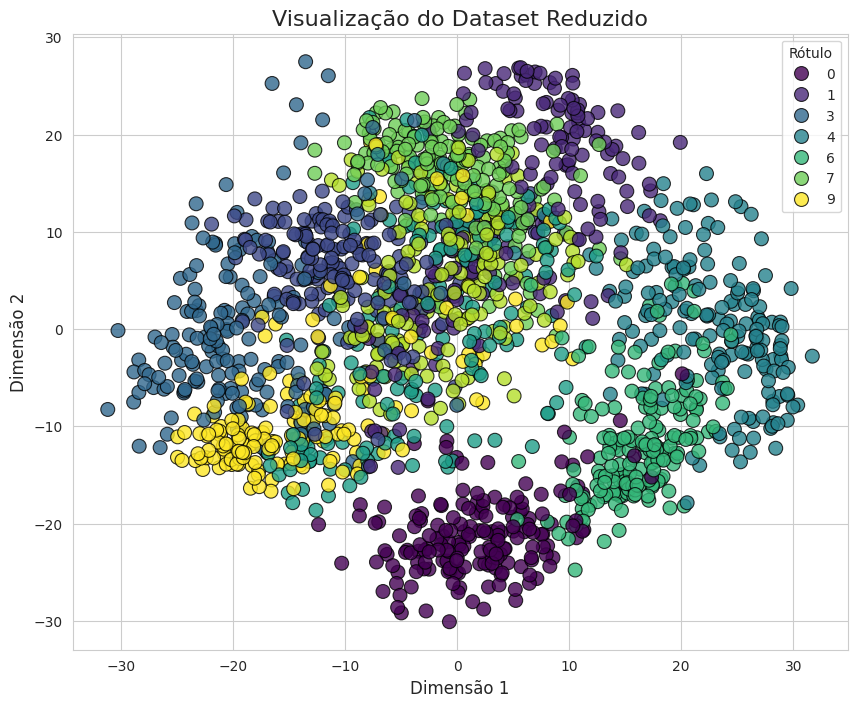

,l1.mean,l2.mean,l3.mean,n1,n2.mean,n3.mean
0,0.058456,0.083329,0.062923,0.528659,0.436041,0.410128


In [8]:
X = load_digits()
X_reduced = reduze_dimensionality(X.data, X.target, n_components=2)
result = calculate_mfe(X_reduced, X.target)
result[feature_cols]